In [7]:
!pip install yfinance pandas matplotlib scikit-learn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Taha\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [9]:
# Select a stock (Apple) and load historical data
ticker = 'AAPL' 
df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

# Preview the data structure
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400490,72.460753,71.156652,71.409755,135480400
2020-01-03,71.696625,72.455943,71.472447,71.629130,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [10]:
# Create the target variable: Tomorrow's close price
df['Next_Close'] = df['Close'].shift(-1)

# Drop rows with missing values (the very last row)
df = df.dropna()

# Select features: Open, High, Low, Volume
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Next_Close']

print("Features and target prepared.")

Features and target prepared.


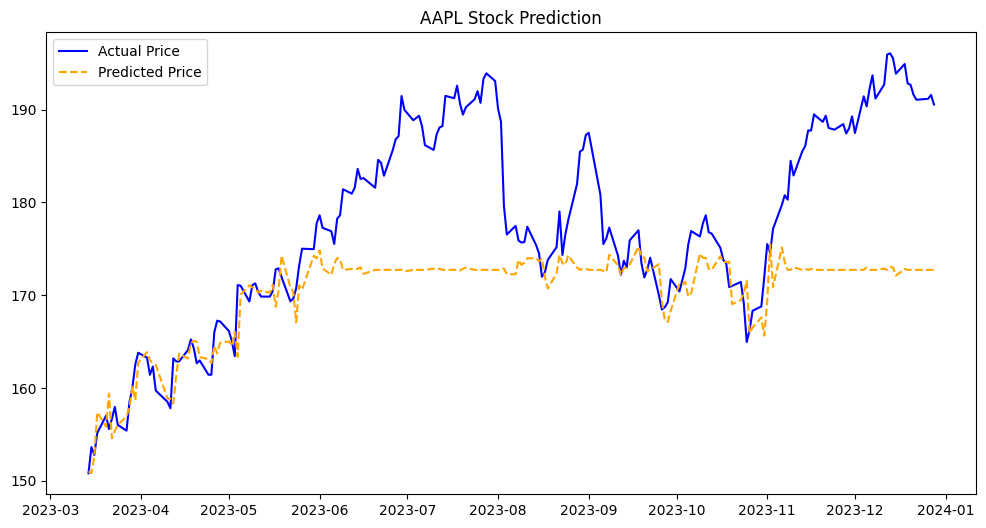

Mean Squared Error: 107.63


In [12]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Initialize and train the Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and Plot
predictions = model.predict(X_test)
results = pd.DataFrame({'Actual': y_test, 'Predicted': predictions}, index=y_test.index)

plt.figure(figsize=(12,6))
plt.plot(results['Actual'], label='Actual Price', color='blue')
plt.plot(results['Predicted'], label='Predicted Price', color='orange', linestyle='--')
plt.title(f'{ticker} Stock Prediction')
plt.legend()
plt.show()

print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.2f}")